## Learning objectives
- Learn how to use `WrapCalibratedExplainer` to wrap a model and produce calibrated predictions;
- Generate factual and alternative explanations and plot uncertainty;
- Understand when OOB vs explicit calibration is appropriate.

## Time to run
~2–10 min depending on dataset and environment (use smaller datasets for a faster run).


# Getting started with calibrated-explanations - using the WrapCalibratedExplainer class
Author: Tuwe Löfström (tuwe.lofstrom@ju.se)  
Copyright 2023 Tuwe Löfström  
License: BSD 3 clause
## Classification
Let us illustrate how we may use `calibrated_explanations` to generate explanations from a classifier trained on a dataset from
[www.openml.org](https://www.openml.org), which we first split into a
training and a test set using `train_test_split` from
[sklearn](https://scikit-learn.org), and then further split the
training set into a proper training set and a calibration set:

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

dataset = fetch_openml(name="wine", version=7, as_frame=True, parser="auto")

X = dataset.data.values.astype(float)
y = (dataset.target.values == "True").astype(int)

feature_names = dataset.feature_names

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=2, stratify=y)

X_prop_train, x_cal, y_prop_train, y_cal = train_test_split(x_train, y_train, test_size=0.25)

We now create our wrapper object, using a `RandomForestClassifier` as learner. 

In [12]:
from sklearn.ensemble import RandomForestClassifier

from calibrated_explanations import WrapCalibratedExplainer, __version__

print(f"calibrated_explanations {__version__}")

classifier = WrapCalibratedExplainer(RandomForestClassifier())
display(classifier)

calibrated_explanations v0.11.3-dev


WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=False, calibrated=False)

We now fit our model using the proper training set.

In [13]:
classifier.fit(X_prop_train, y_prop_train)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=False)

The `WrapCalibratedExplainer` class has a `predict` and a `predict_proba` method that returns the predictions and probability estimates of the underlying classifier. If the model is not yet calibrated, then the underlying models `predict` and `predict_proba` methods are used. If the model is calibrated, then the `predict` and `predict_proba` method of the calibration model is used.

In [14]:
prediction = classifier.predict(x_test)
proba = classifier.predict_proba(x_test)
print("Uncalibrated prediction (probability estimates):")
print(f"{prediction} ({proba})")

Uncalibrated prediction (probability estimates):
[1 0] ([[0.25 0.75]
 [0.7  0.3 ]])


C:\Users\loftuw\AppData\Local\Temp\ipykernel_92976\1092592062.py:1: UserWarning: The WrapCalibratedExplainer must be calibrated to get calibrated predictions.
  prediction = classifier.predict(x_test)
C:\Users\loftuw\AppData\Local\Temp\ipykernel_92976\1092592062.py:2: UserWarning: The WrapCalibratedExplainer must be calibrated to get calibrated probabilities.
  proba = classifier.predict_proba(x_test)


Before we can generate explanations, we need to calibrate our model using the calibration set. 

In [15]:
classifier.calibrate(x_cal, y_cal, feature_names=feature_names)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, learner=RandomForestClassifier()))

Once the model is calibrated, the `predict` and `predict_proba` methods produce calibrated predictions and probability estimates.

In [16]:
prediction = classifier.predict(x_test)
proba, (low, high) = classifier.predict_proba(x_test, uq_interval=True)
print("Calibrated prediction (probability estimates):")
print(f"{prediction} ({proba})")
print("Calibrated uncertainty interval for the positive class:")
print([(low[i], high[i]) for i in range(len(low))])

Calibrated prediction (probability estimates):
['1' '0'] ([[0.10791367 0.89208633]
 [0.8045977  0.1954023 ]])
Calibrated uncertainty interval for the positive class:
[(np.float64(0.8913043478260869), np.float64(0.8985507246376812)), (np.float64(0.17647058823529413), np.float64(0.2))]


#### Factual Explanations
Let us explain a test instance using our `WrapCalibratedExplainer` object. The method used to get factual explanations is `explain_guarded_factual`. 

In [17]:
factual_explanations = classifier.explain_factual(x_test)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, discretizer=BinaryEntropyDiscretizer(), learner=RandomForestClassifier()))

In [18]:
factual_explanations.plot()
factual_explanations.plot(uncertainty=True)

KeyError: 5

In [ ]:
factual_explanations = classifier.explain_guarded_factual(x_test)
from calibrated_explanations.ce_agent_utils import print_guarded_audit_table

guarded_audit = factual_explanations.get_guarded_audit()
print_guarded_audit_table(guarded_audit, max_rows=20)
display(classifier)

Guarded Audit Summary
instances=2 tested=170 conforming=134 removed_guard=36 emitted=21
inst feat name                interval                  p      conf emit mrg  reason
------------------------------------------------------------------------------------
   0    0 fixed acidity      (-inf, 5.65]             0.3918  Y    N    N   design_excluded
   0    0 fixed acidity      (5.65, 6.05]             0.5392  Y    N    N   design_excluded
   0    0 fixed acidity      (6.05, 6.55]             0.6426  Y    N    N   design_excluded
   0    0 fixed acidity      (6.55, 7.05]             0.6818  Y    N    N   design_excluded
   0    0 fixed acidity      (7.05, 10.35]            0.6426  Y    Y    N   emitted
   0    0 fixed acidity      (10.35, 11.9]            0.0533  N    N    N   removed_guard
   0    0 fixed acidity      (11.9, 14.5]             0.0188  N    N    N   removed_guard
   0    0 fixed acidity      (14.5, inf]              0.0031  N    N    N   removed_guard
   0    1 volatile a

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, discretizer=EntropyDiscretizer(), learner=RandomForestClassifier()))

#### Merge adjacent conforming bins
Passing  collapses adjacent conforming bins into wider rules (re-tested by the guard).  Rows with  in the audit table came from a merge; the displayed interval shows the emitted bounds.

In [ ]:
merged_factual_cls = classifier.explain_guarded_factual(x_test, merge_adjacent=True)
merged_audit_cls = merged_factual_cls.get_guarded_audit()
print_guarded_audit_table(merged_audit_cls, max_rows=30)

Guarded Audit Summary
instances=2 tested=58 conforming=22 removed_guard=36 emitted=10
inst feat name                interval                  p      conf emit mrg  reason
------------------------------------------------------------------------------------
   0    0 fixed acidity      (-inf, 10.35]            0.6834  Y    N    Y   zero_impact
   0    0 fixed acidity      (10.35, 11.9]            0.0533  N    N    N   removed_guard
   0    0 fixed acidity      (11.9, 14.5]             0.0188  N    N    N   removed_guard
   0    0 fixed acidity      (14.5, inf]              0.0031  N    N    N   removed_guard
   0    1 volatile acidity   (-inf, 0.535]            0.5423  Y    Y    Y   emitted
   0    1 volatile acidity   (0.535, 0.6575]          0.0721  N    N    N   removed_guard
   0    1 volatile acidity   (0.6575, 0.665]          0.0423  N    N    N   removed_guard
   0    1 volatile acidity   (0.665, 0.795]           0.0251  N    N    N   removed_guard
   0    1 volatile acidity   (0.

Once we have the explanations, we can plot all of them using `plot`. Default, a regular plot, without uncertainty intervals included, is created. To include uncertainty intervals, change the parameter `uncertainty=True`.

C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


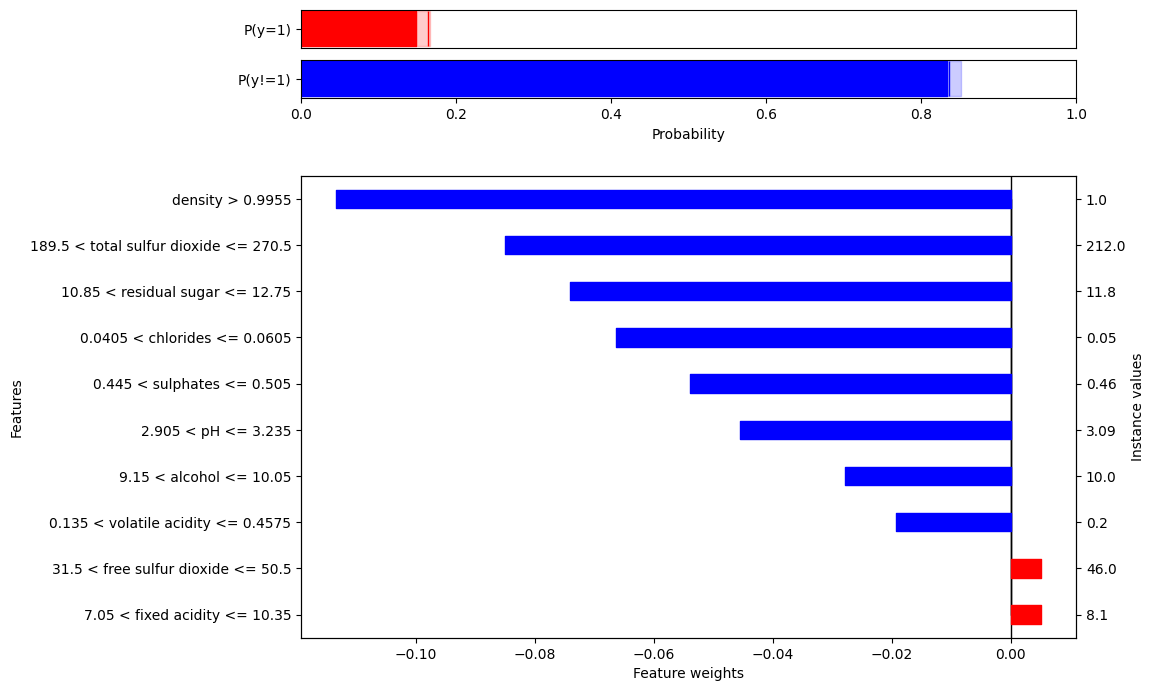

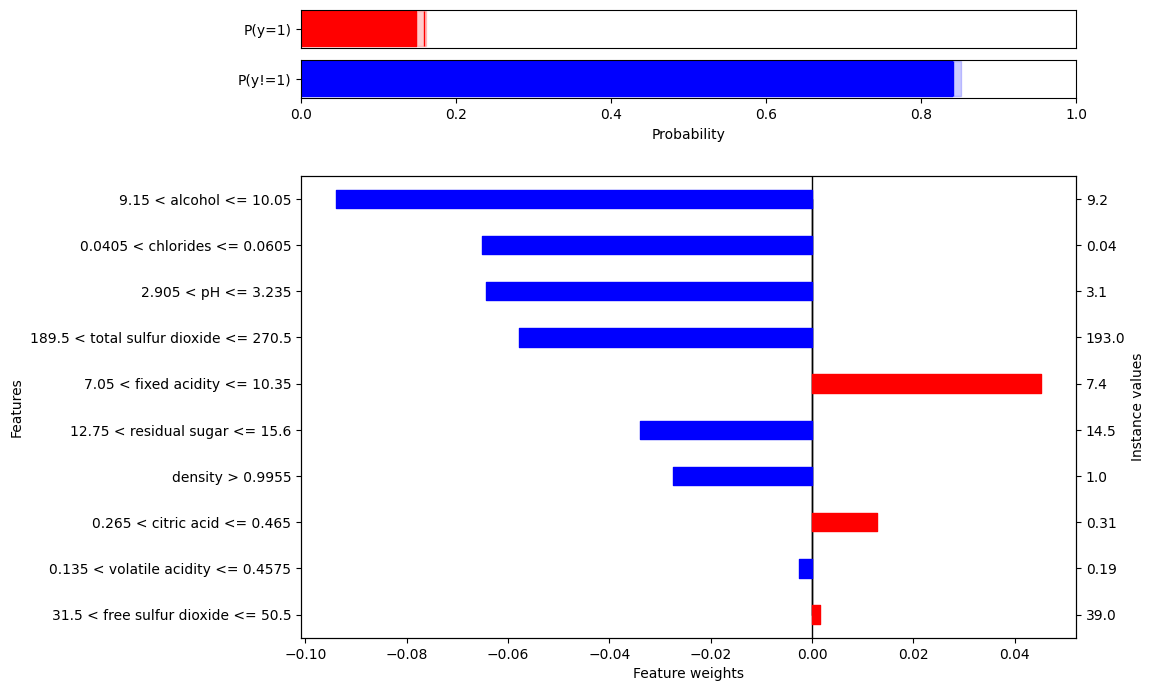

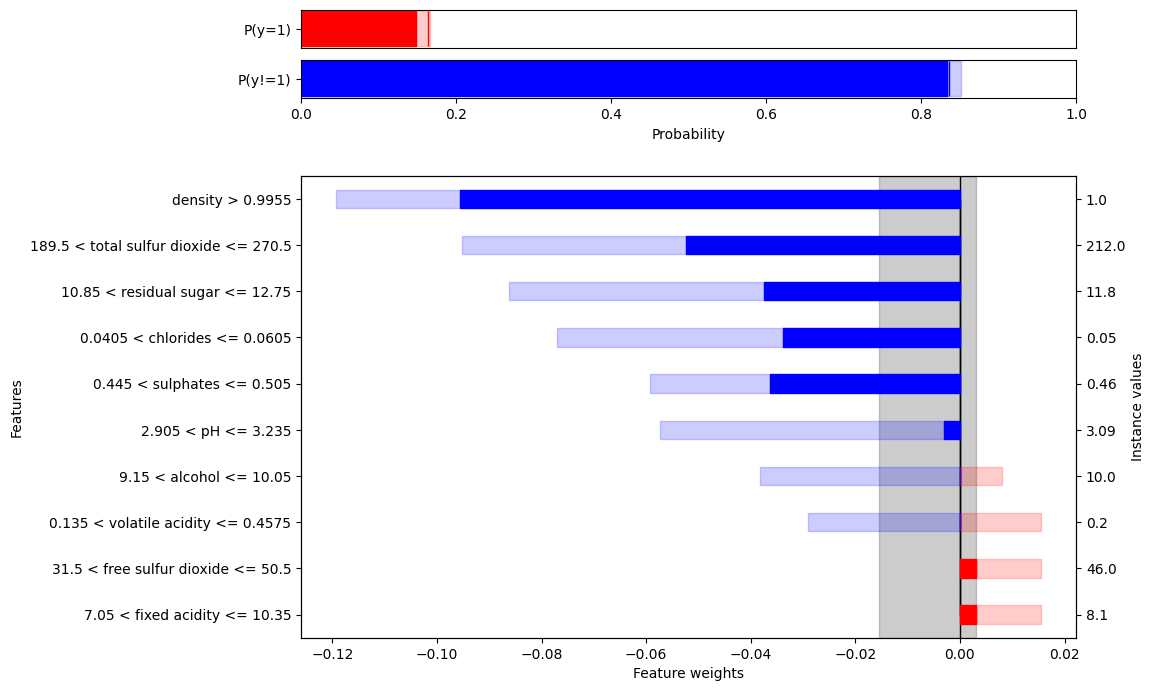

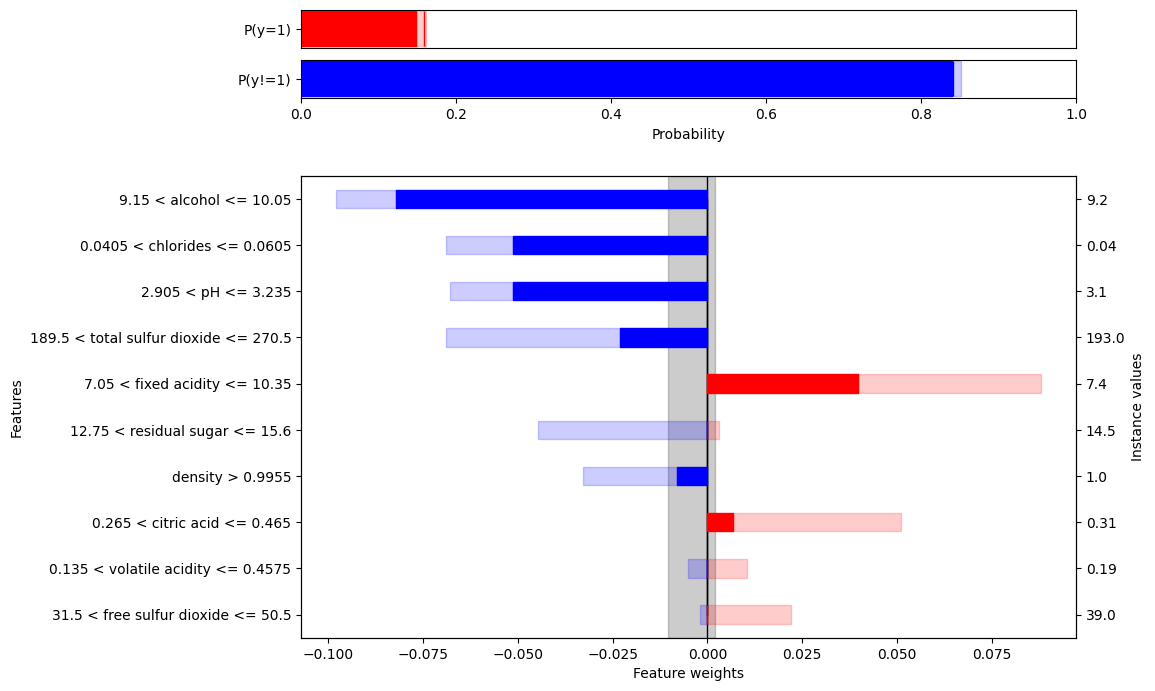

In [ ]:
factual_explanations.plot()
factual_explanations.plot(uncertainty=True)

You can also add and remove conjunctive rules.

C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


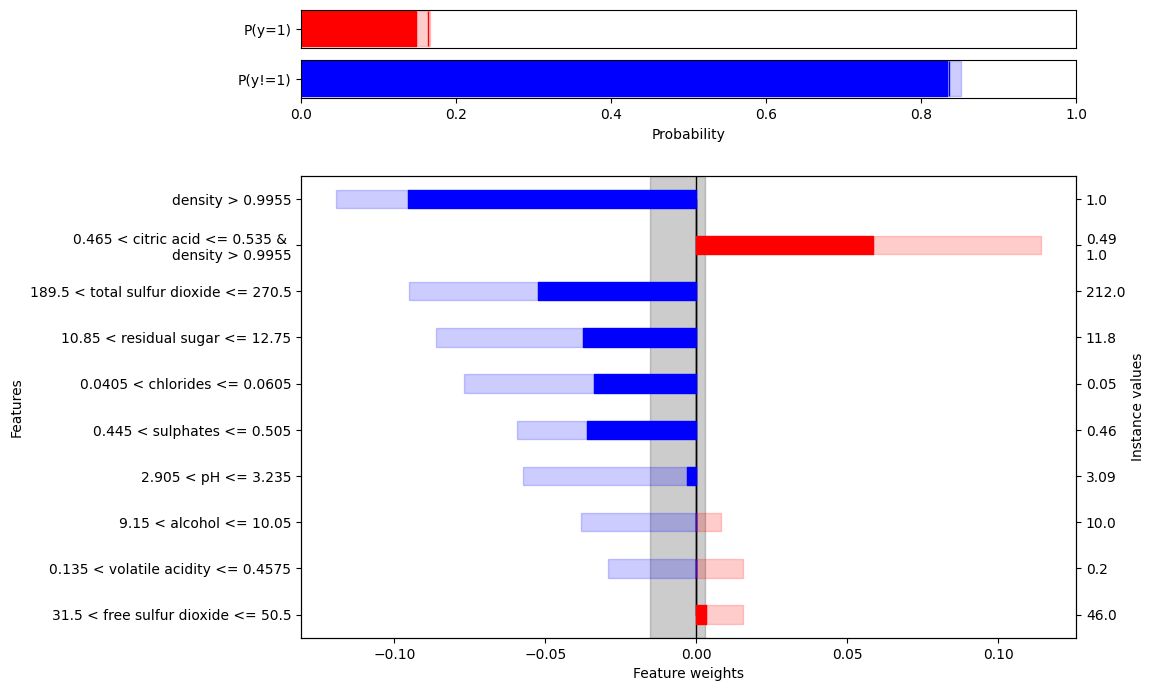

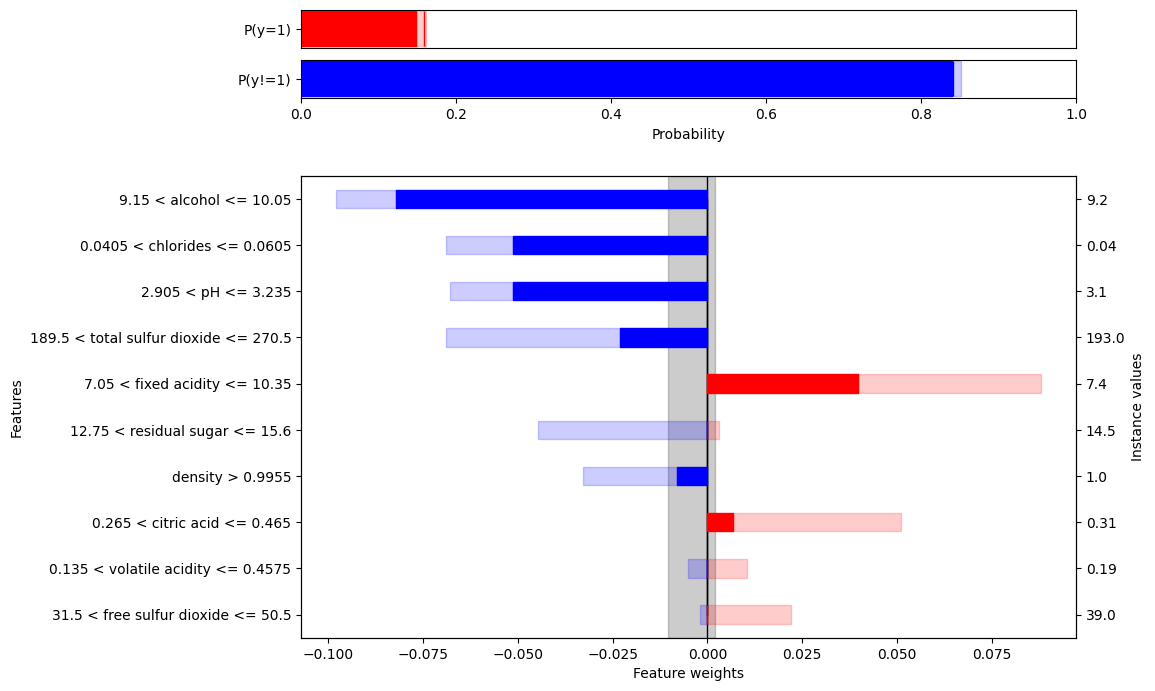

In [ ]:
factual_explanations.add_conjunctions().plot(uncertainty=True)

All explanations support indexing using integer indexing, slices or boolean indexing.

C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


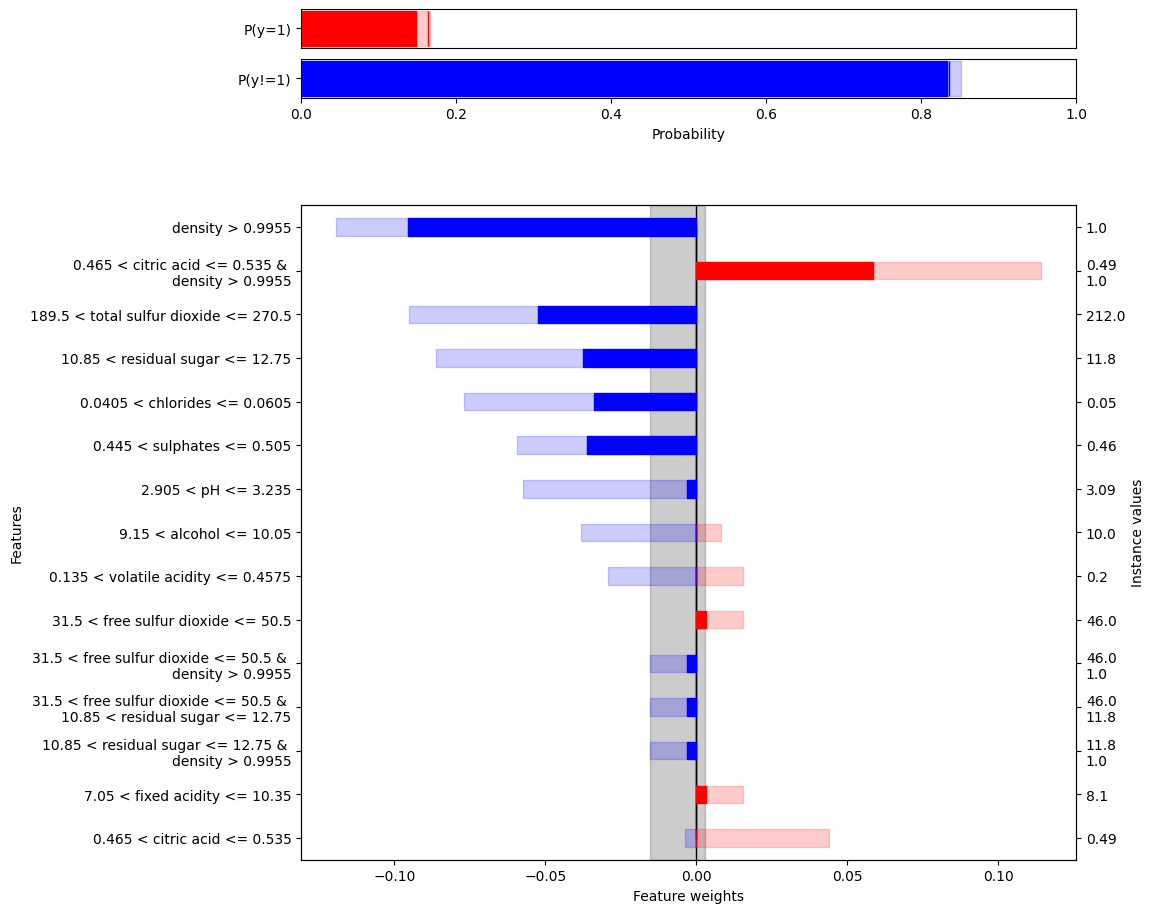

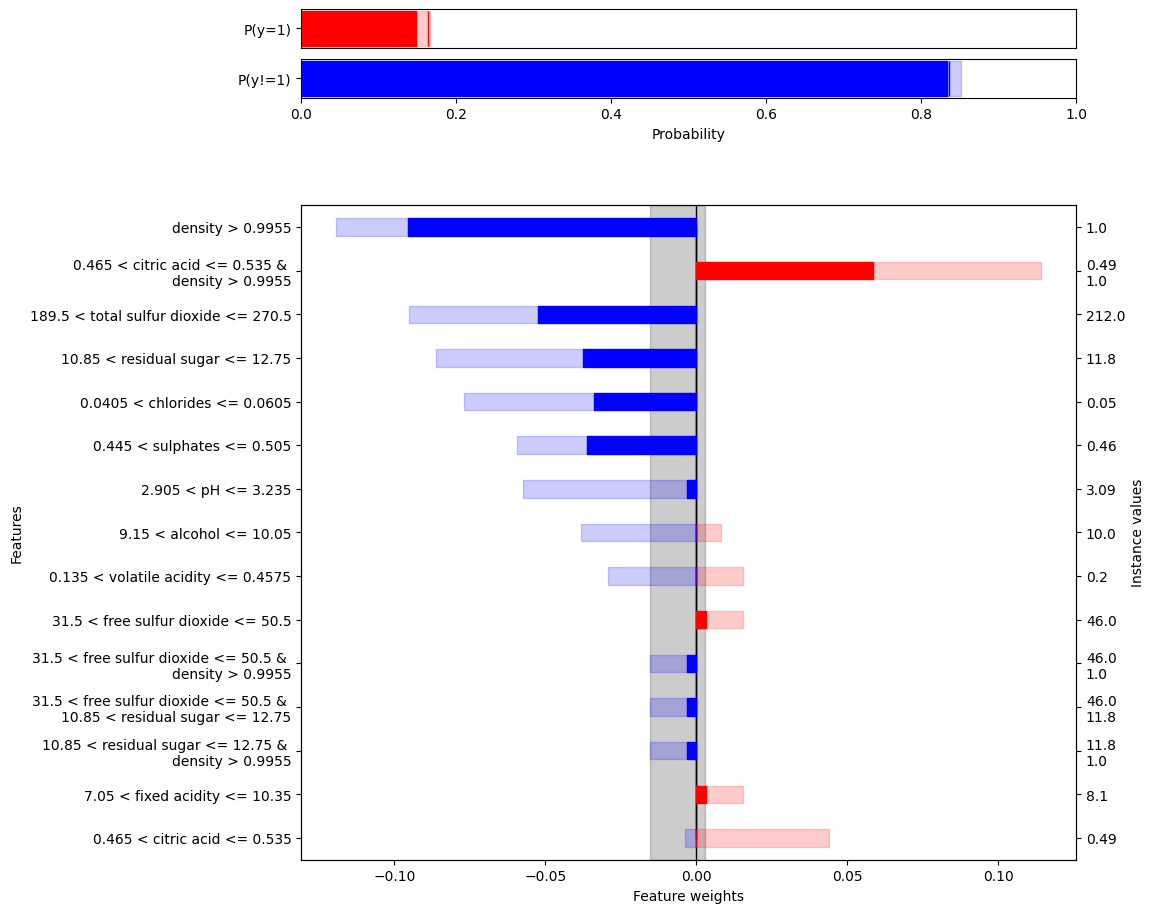

In [ ]:
factual_explanations[0].plot(uncertainty=True)
factual_explanations[:1].plot(uncertainty=True)

#### Explore Alternative Explanations
An alternative to factual rules is to extract alternative rules, which is done using the `explore_guarded_alternatives` function. Alternative explanations provides insights on how predicted outcomes would change if specific input features were modified, including uncertainty estimates for these alternative outcomes.

In [ ]:
alternative_explanations = classifier.explore_guarded_alternatives(x_test)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, discretizer=EntropyDiscretizer(), learner=RandomForestClassifier()))

Alternatives are also visualized using the `plot` function. Plotting an individual alternative explanation is easiest done using indexing. Adding or removing conjunctions is done as before.

C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


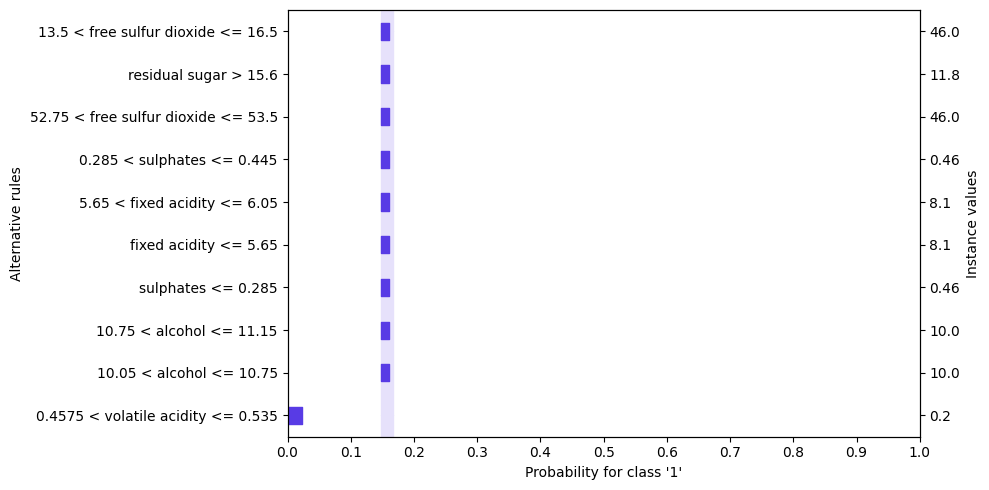

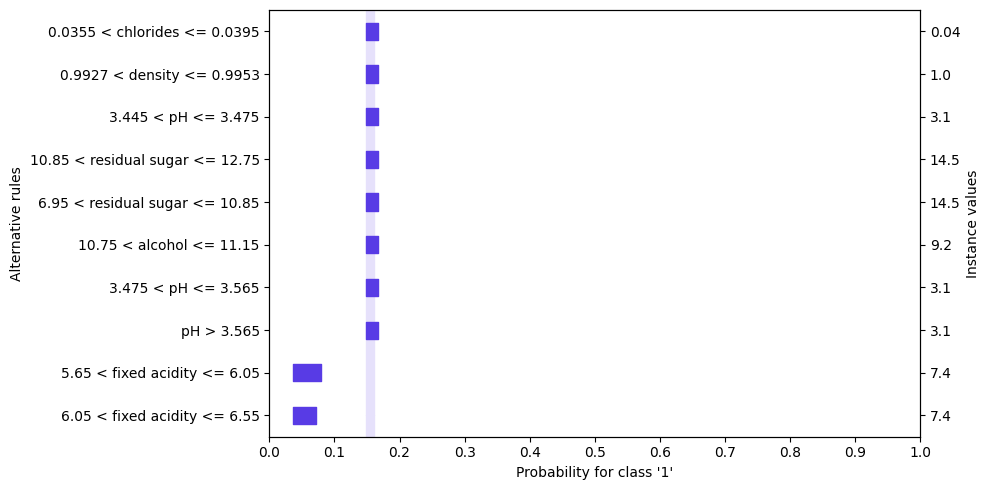

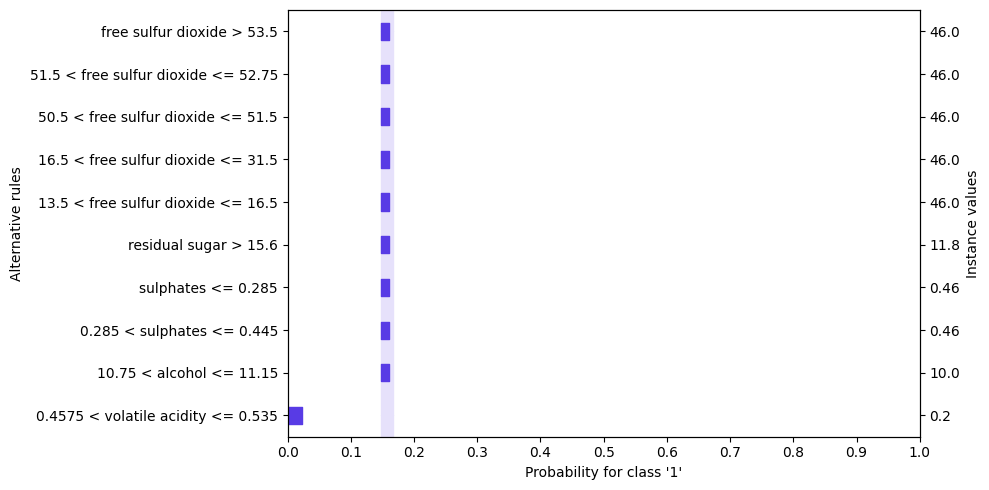

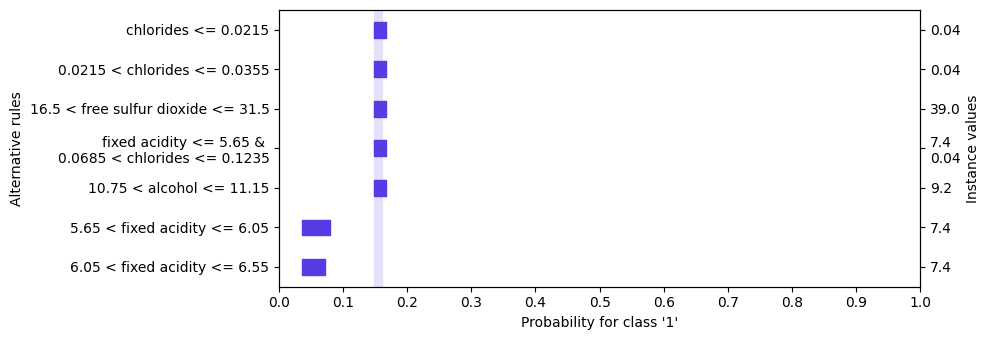

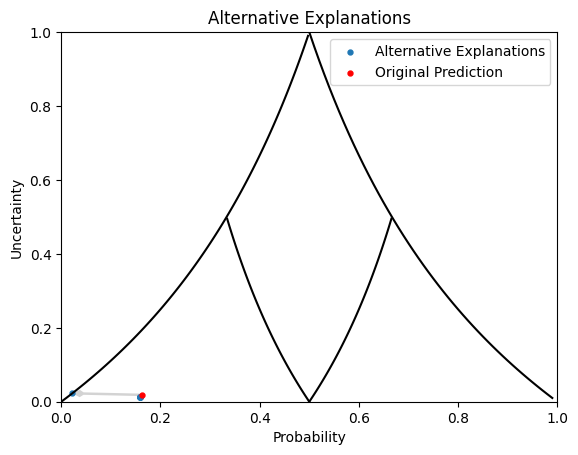

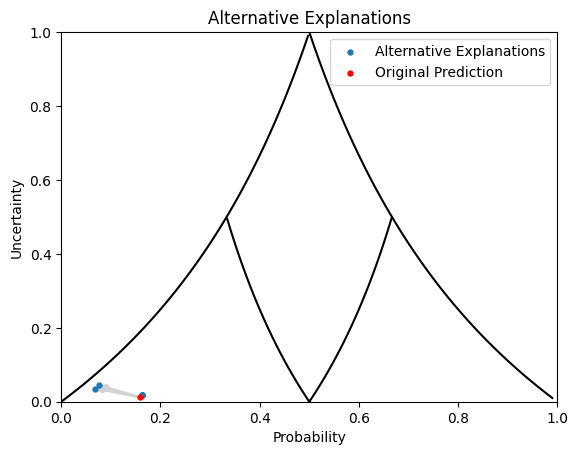


Instance 0

Alternative Explanation (Advanced):
--------------------------------------------------------------------------------
Prediction: 1
Calibrated probability: 0.164
Prediction Interval: [0.148, 0.167]

Alternatives to increase the calibrated probability for class 1:
- If (volatile acidity <= 0.1025 AND 72 < total sulfur dioxide <= 101.5)         then 0.526 [0.520, 0.533]
- If sulphates 0.765 < sulphates <= 1.115                                        then 0.344 [0.333, 0.349]
- If density 0.9919 < density <= 0.9921                                          then 0.344 [0.333, 0.349]
- If density 0.9921 < density <= 0.9927                                          then 0.344 [0.333, 0.349]
- If density 0.9927 < density <= 0.9953                                          then 0.344 [0.333, 0.349]
- If (2.89 < pH <= 2.905 AND 72 < total sulfur dioxide <= 101.5)                 then 0.344 [0.333, 0.349]
- If total sulfur dioxide 72 < total sulfur dioxide <= 101.5                     t

In [ ]:
alternative_explanations.plot()
alternative_explanations.add_conjunctions().plot()
alternative_explanations.add_conjunctions().plot(style="ensured")
print(alternative_explanations.to_narrative(output_format="text"))

`calibrated_explanations` supports multiclass which is demonstrated in [demo_multiclass](https://github.com/Moffran/calibrated_explanations/blob/main/notebooks/demo_multiclass.ipynb). That notebook also demonstrates how both feature names and target and categorical labels can be added to improve the interpretability. 
## Regression
Extracting explanations for regression is very similar to how it is done for classification. First we load and divide the dataset. The target is divided by 1000, meaning that the target is in thousands of dollars. 

In [ ]:
dataset = fetch_openml(name="house_sales", version=3)

X = dataset.data.values.astype(float)
y = dataset.target.values / 1000
y_filter = y < 500
X = X[y_filter, :]
y = y[y_filter]

feature_names = dataset.feature_names
categorical_labels = {5: {0: "False", 1: "True"}}

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=2, random_state=42, stratify=X[:, 5]
)

X_prop_train, x_cal, y_prop_train, y_cal = train_test_split(
    x_train, y_train, random_state=42, test_size=500, stratify=x_train[:, 5]
)

We now create our wrapper object, using a `RandomForestRegressor` as learner. 

In [ ]:
from sklearn.ensemble import RandomForestRegressor

regressor = WrapCalibratedExplainer(RandomForestRegressor())
display(regressor)

WrapCalibratedExplainer(learner=RandomForestRegressor(), fitted=False, calibrated=False)

We now fit our model using the proper training set.

In [ ]:
regressor.fit(X_prop_train, y_prop_train)
display(regressor)

WrapCalibratedExplainer(learner=RandomForestRegressor(), fitted=True, calibrated=False)

The `WrapCalibratedExplainer` class has a `predict` method that returns the predictions and probability estimates of the underlying classifier. If the model is not yet calibrated, then the underlying models `predict` method is used. If the model is calibrated, then the `predict` method of the calibration model is used.

In [ ]:
prediction = regressor.predict(x_test)
print(f"Uncalibrated model prediction: \n{prediction}")

Uncalibrated model prediction: 
[296.7155 408.7005]


C:\Users\loftuw\AppData\Local\Temp\ipykernel_66976\1346691177.py:1: UserWarning: The WrapCalibratedExplainer must be calibrated to get calibrated predictions.
  prediction = regressor.predict(x_test)


Before we can generate explanations, we need to calibrate our model using the calibration set. 

In [ ]:
regressor.calibrate(
    x_cal, y_cal, feature_names=feature_names, categorical_labels=categorical_labels
)
display(regressor)

WrapCalibratedExplainer(learner=RandomForestRegressor(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=regression, learner=RandomForestRegressor(), difficulty_estimator=None))

We can easily add a difficulty estimator by assigning a `DifficultyEstimator` to the `difficulty_estimator` attribute when calibrating the model.

In [ ]:
from crepes.extras import DifficultyEstimator

de = DifficultyEstimator().fit(X=X_prop_train, learner=regressor.learner, scaler=True)
regressor.calibrate(
    x_cal,
    y_cal,
    feature_names=feature_names,
    difficulty_estimator=de,
    categorical_labels=categorical_labels,
)
display(regressor)

WrapCalibratedExplainer(learner=RandomForestRegressor(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=regression, learner=RandomForestRegressor(), difficulty_estimator=DifficultyEstimator(fitted=True, type=variance, scaler=True, beta=0.01, oob=False)))

Once the model is calibrated, the `predict`  method produce calibrated predictions with uncertainties. The default confidence is 90 per cent, which can be altered using the `low_high_percentiles` parameter. 

In [ ]:
prediction, (low, high) = regressor.predict(
    x_test, uq_interval=True
)  # default low_high_percentiles=(5, 95)
print(f"Calibrated prediction: \n{prediction}")
print("Calibrated uncertainty interval:")
print([(low[i], high[i]) for i in range(len(low))])

Calibrated prediction: 
[297.05103553 408.98711679]
Calibrated uncertainty interval:
[(np.float64(261.63294997032125), np.float64(323.16935367997763)), (np.float64(378.73274059776725), np.float64(431.2975666805231))]


You can also get the probability of the prediction being below a certain threshold using `predict_proba` by assigning the `threshold` parameter.

In [ ]:
import numpy as np

prediction = regressor.predict(x_test, threshold=200)
print("Calibrated probabilistic prediction:")
print(prediction)

proba, (low, high) = regressor.predict_proba(x_test, uq_interval=True, threshold=200)
print("Calibrated probabilistic probability estimate [y_hat > threshold, y_hat <= threshold]:")
print(proba)
print(
    "Calibrated probabilistic uncertainty interval for y_hat <= threshold ([lower_bound, upper_bound]):"
)
print(np.array([(low[i], high[i]) for i in range(len(low))]))

Calibrated probabilistic prediction:
['y_hat > 200', 'y_hat > 200']
Calibrated probabilistic probability estimate [y_hat > threshold, y_hat <= threshold]:
[[0.98412698 0.01587302]
 [0.98666667 0.01333333]]
Calibrated probabilistic uncertainty interval for y_hat <= threshold ([lower_bound, upper_bound]):
[[0.         0.01612903]
 [0.         0.01351351]]


#### Factual Explanations
Let us explain a test instance using our `WrapCalibratedExplainer` object. The method used to get factual explanations is `explain_guarded_factual`. 

In [ ]:
factual_explanations = regressor.explain_guarded_factual(x_test)
from calibrated_explanations.ce_agent_utils import print_guarded_audit_table

guarded_audit = factual_explanations.get_guarded_audit()
print_guarded_audit_table(guarded_audit, max_rows=20)
display(regressor)

Guarded Audit Summary
instances=2 tested=262 conforming=239 removed_guard=23 emitted=36
inst feat name                interval                  p      conf emit mrg  reason
------------------------------------------------------------------------------------
   0    0 bedrooms           (-inf, 1.5]                 0.5  Y    N    N   design_excluded
   0    0 bedrooms           (1.5, 2.5]                0.878  Y    N    N   design_excluded
   0    0 bedrooms           (2.5, 3.5]                0.986  Y    Y    N   emitted
   0    0 bedrooms           (3.5, 4.5]                 0.95  Y    N    N   design_excluded
   0    0 bedrooms           (4.5, 5.5]                0.692  Y    N    N   design_excluded
   0    0 bedrooms           (5.5, inf]                 0.37  Y    N    N   design_excluded
   0    1 bathrooms          (-inf, 0.875]              0.77  Y    N    N   design_excluded
   0    1 bathrooms          (0.875, 1.25]             0.886  Y    N    N   design_excluded
   0    1 bath

WrapCalibratedExplainer(learner=RandomForestRegressor(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=regression, discretizer=RegressorDiscretizer(), learner=RandomForestRegressor(), difficulty_estimator=DifficultyEstimator(fitted=True, type=variance, scaler=True, beta=0.01, oob=False)))

#### Merge adjacent conforming bins
By default, guarded explanations keep each bin as a separate rule.  Passing  allows adjacent conforming bins to be collapsed into a single wider rule.  The merged rule is re-tested by the guard; if the re-test fails, the original bins are kept.  The  column in the audit table shows which emitted rules came from a merge.

In [ ]:
merged_factual = regressor.explain_guarded_factual(x_test, merge_adjacent=True)
merged_audit = merged_factual.get_guarded_audit()
print_guarded_audit_table(merged_audit, max_rows=30)

Guarded Audit Summary
instances=2 tested=65 conforming=42 removed_guard=23 emitted=28
inst feat name                interval                  p      conf emit mrg  reason
------------------------------------------------------------------------------------
   0    0 bedrooms           (-inf, inf]               0.986  Y    N    Y   zero_impact
   0    1 bathrooms          (-inf, inf]                0.99  Y    Y    Y   emitted
   0    2 sqft_living        (-inf, inf]                0.98  Y    Y    Y   emitted
   0    3 sqft_lot           (-inf, inf]               0.986  Y    Y    Y   emitted
   0    4 floors             (-inf, 2.75]              0.986  Y    N    Y   zero_impact
   0    4 floors             (2.75, inf]               0.098  N    N    N   removed_guard
   0    5 waterfront         (-inf, inf]               0.986  Y    N    N   zero_impact
   0    5 waterfront         (-inf, inf]               0.004  N    N    N   removed_guard
   0    6 view               (-inf, 3.5]        

Regression also offer both regular and uncertainty plots for factual explanations with or without conjunctive rules, in almost exactly the same way as for classification. 

C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:367: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:367: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:367: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:367: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:367: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Docu

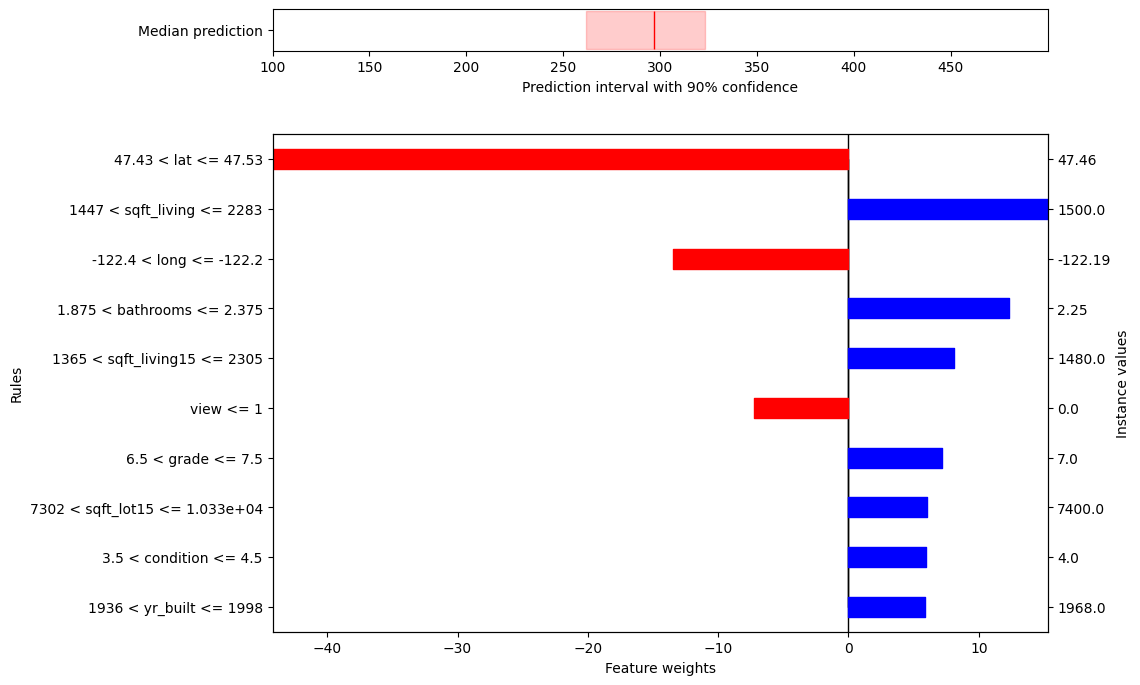

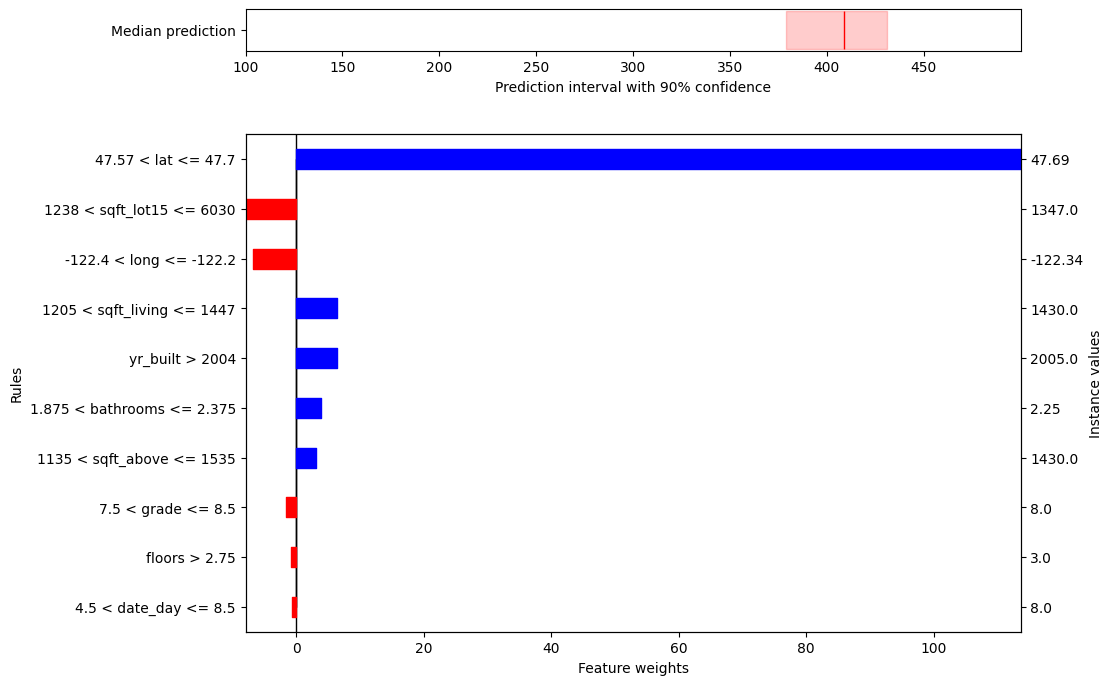

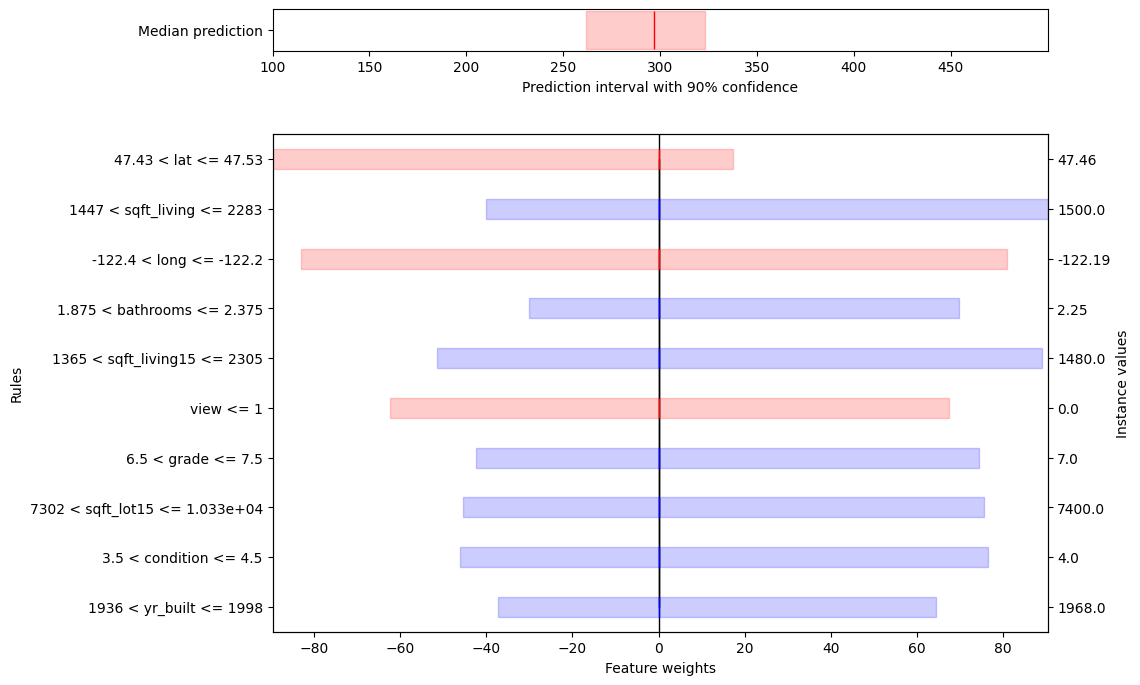

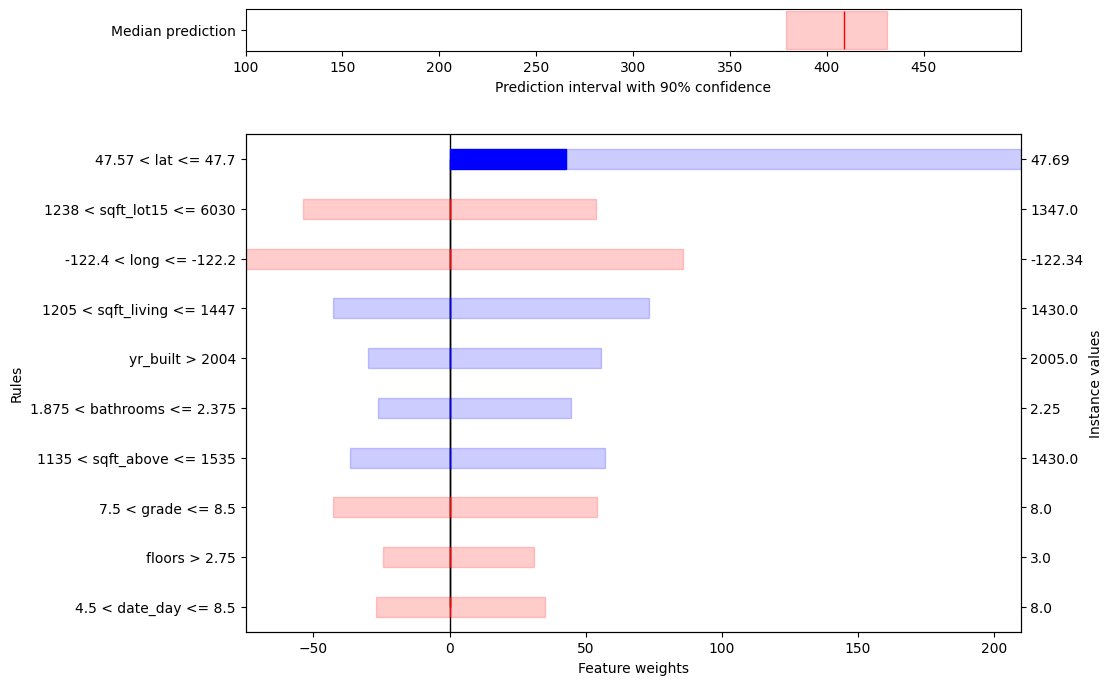

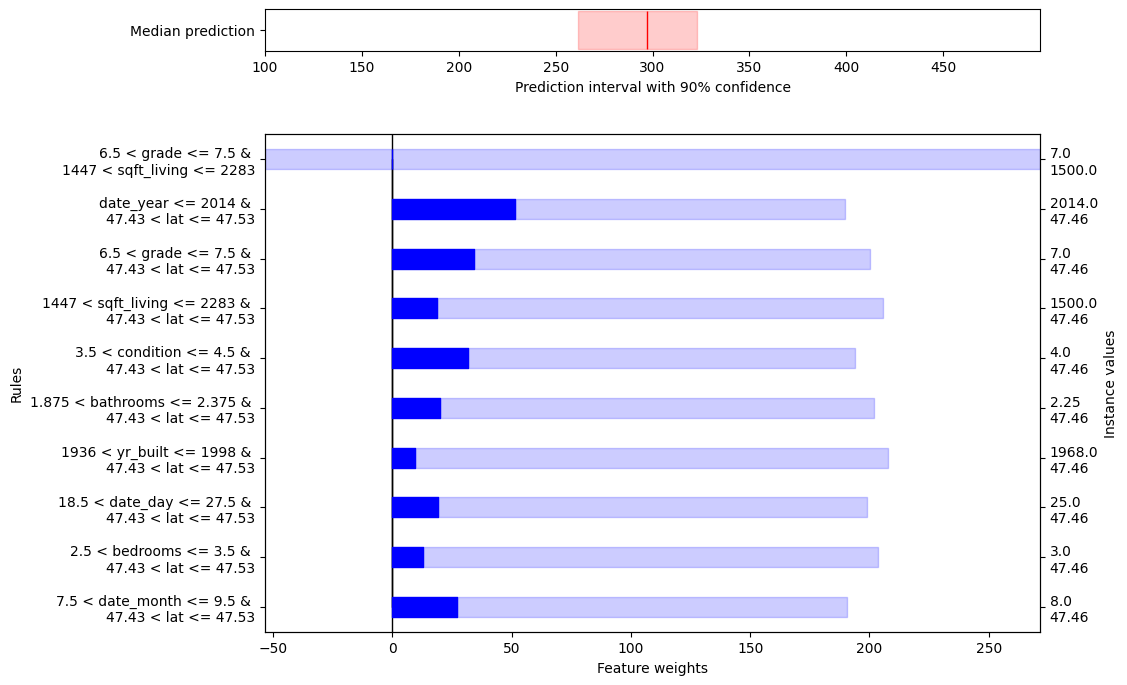

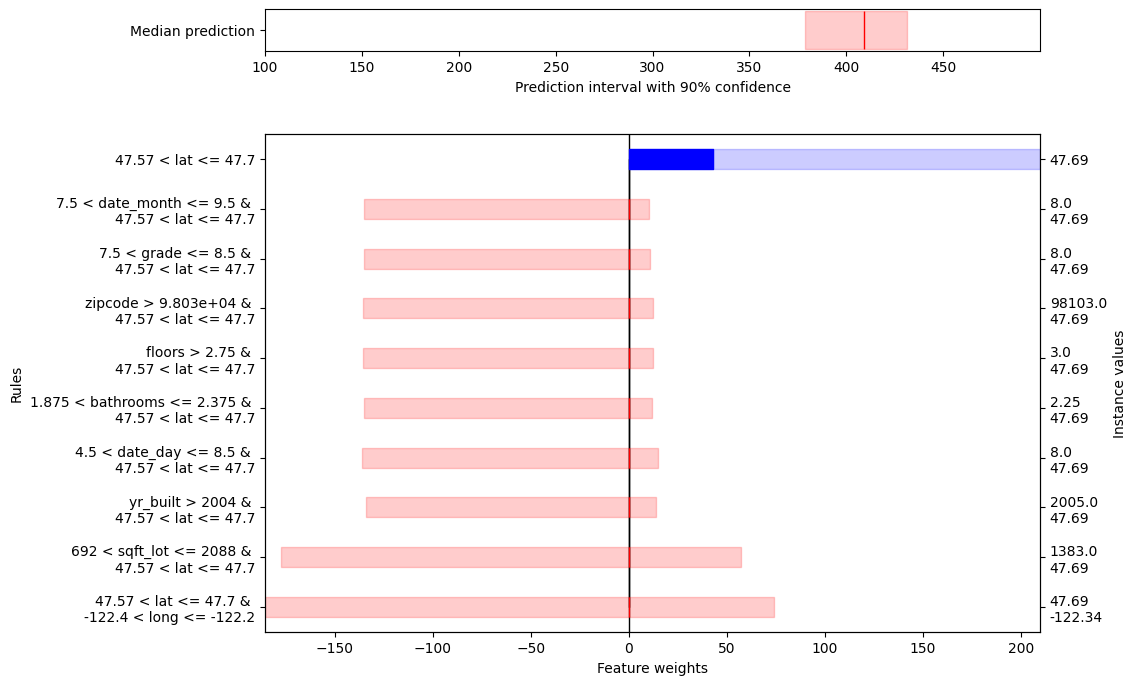

In [ ]:
factual_explanations.plot()
factual_explanations.plot(uncertainty=True)

factual_explanations.add_conjunctions().plot(uncertainty=True)

Default, the confidence interval is set to a symmetric interval of 90% (defined as `low_high_percentiles=(5,95)`). The intervals can cover any user specified interval, including one-sided intervals. To define a one-sided upper-bounded 90% interval, set `low_high_percentiles=(-np.inf,90)`, and to define a one-sided lower-bounded 95% interval, set `low_high_percentiles=(5,np.inf)`. Percentiles can also be set to any other values in the range (0,100) (exclusive), and intervals do not have to be symmetric. 

In [ ]:
lower_bounded_explanations = regressor.explain_guarded_factual(x_test, low_high_percentiles=(5, np.inf))
asymmetric_explanations = regressor.explain_guarded_factual(x_test, low_high_percentiles=(5, 75))

#### Explore Alternative Explanations
The `explore_guarded_alternatives` will work exactly the same as for classification. 

In [ ]:
alternative_explanations = regressor.explore_guarded_alternatives(x_test)
display(regressor)

WrapCalibratedExplainer(learner=RandomForestRegressor(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=regression, discretizer=RegressorDiscretizer(), learner=RandomForestRegressor(), difficulty_estimator=DifficultyEstimator(fitted=True, type=variance, scaler=True, beta=0.01, oob=False)))

Alternative plots work as for classification.

C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


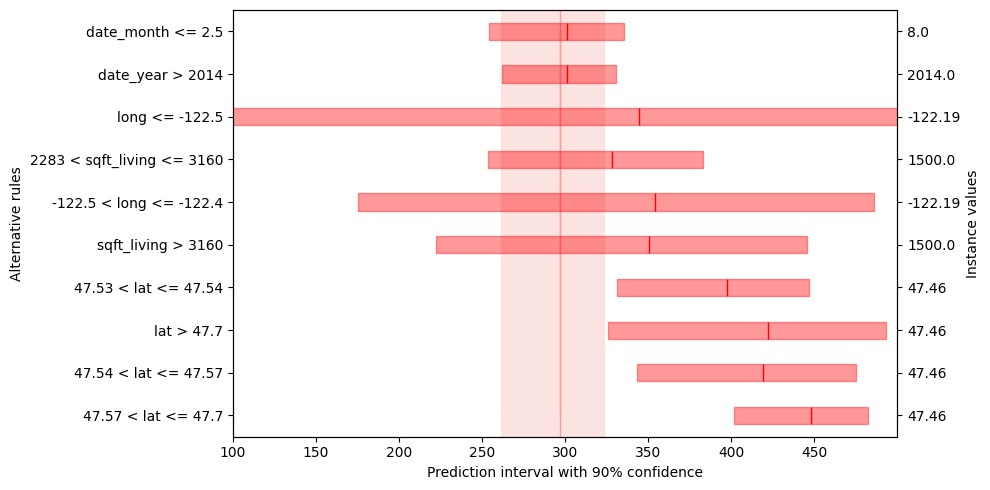

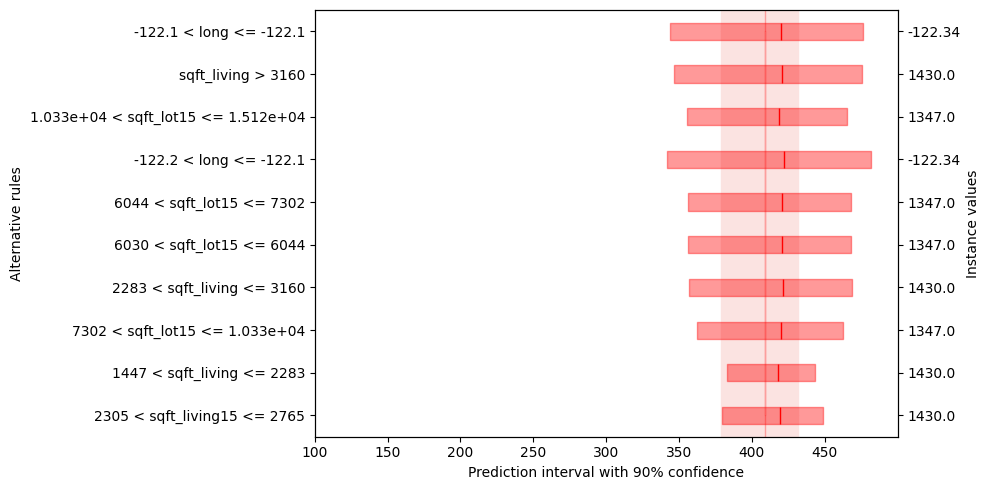

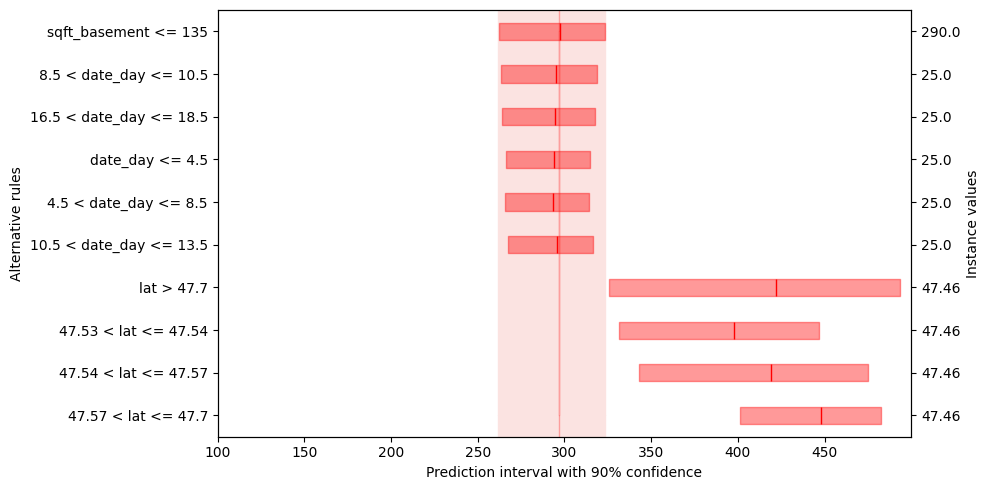

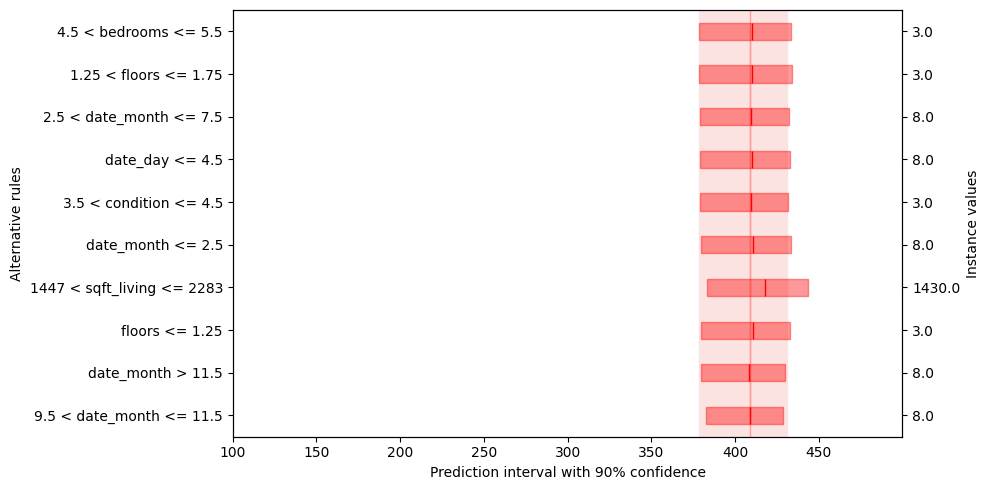

In [ ]:
alternative_explanations.plot(rnk_metric="ensured", rnk_weight=0.9)
alternative_explanations.add_conjunctions().plot()

## Probabilistic Regression
The difference between probabilistic regression and regular regression is that the former returns a probability of the prediction being below a certain threshold. This could for example be useful when the prediction is a time to an event, such as time to death or time to failure. 

C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


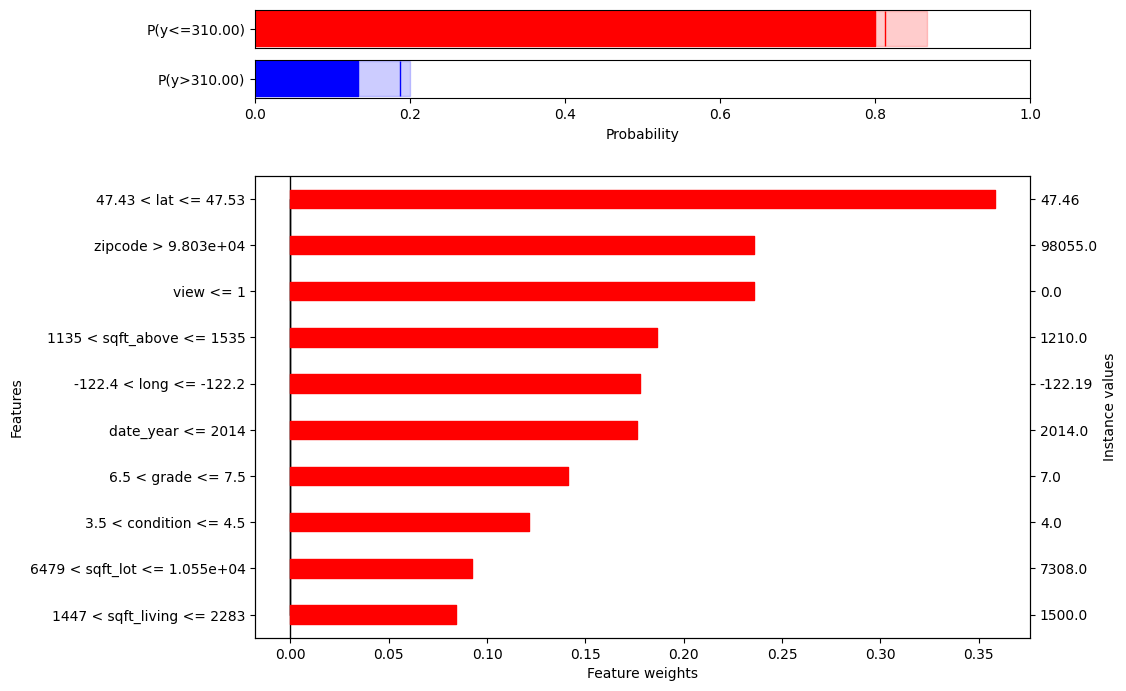

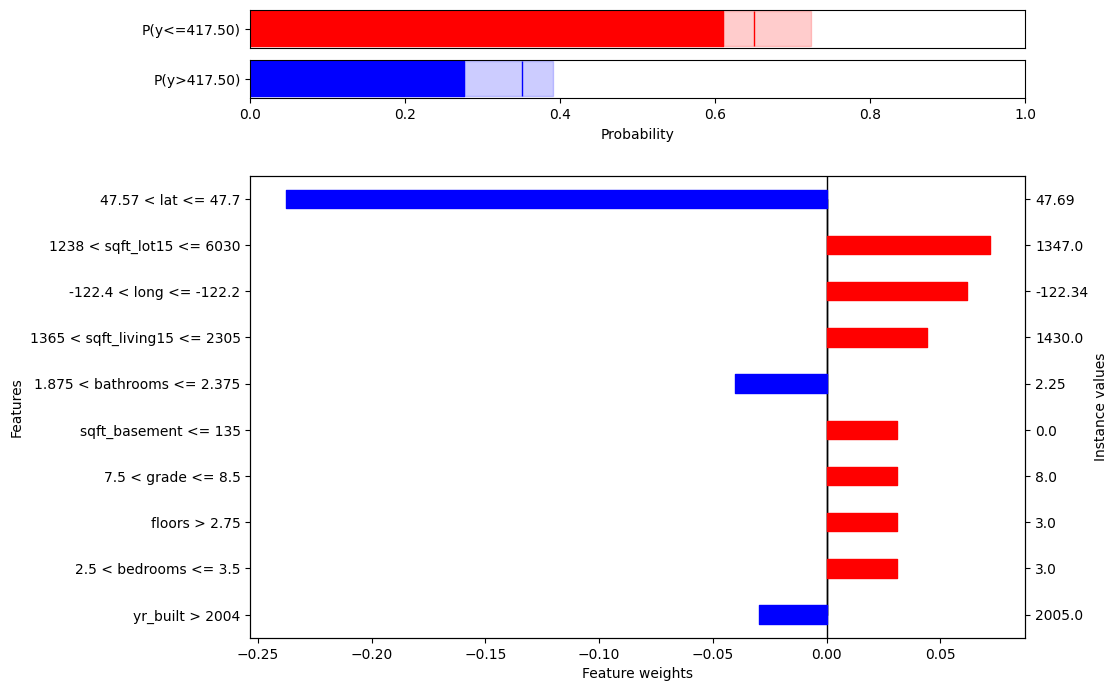

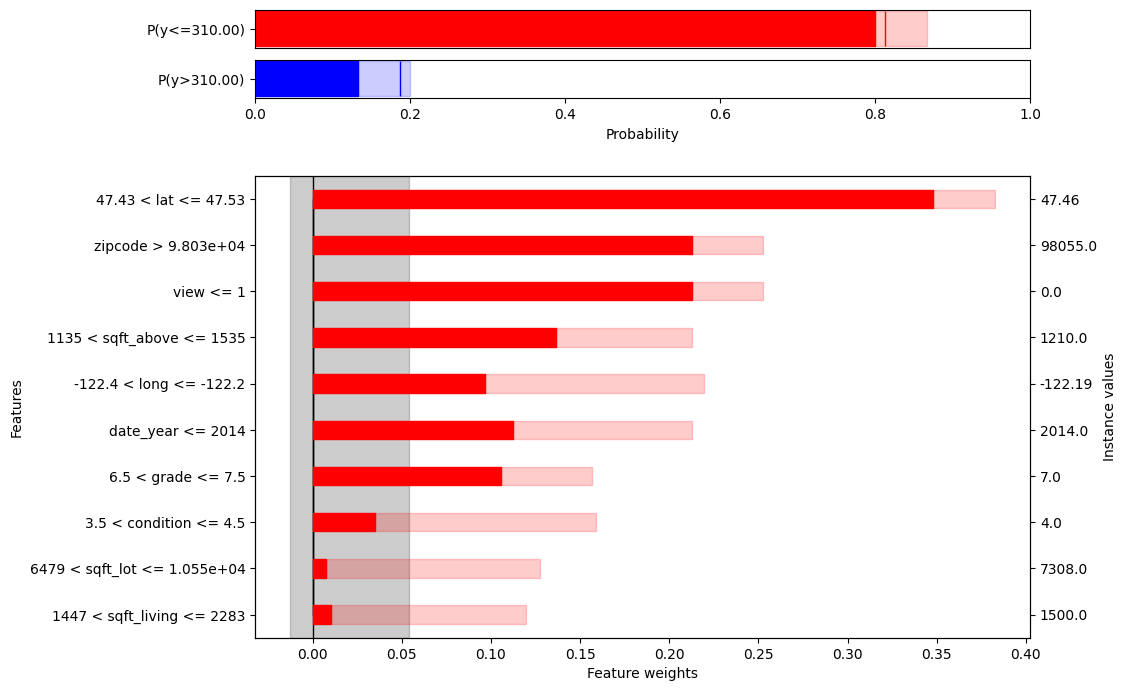

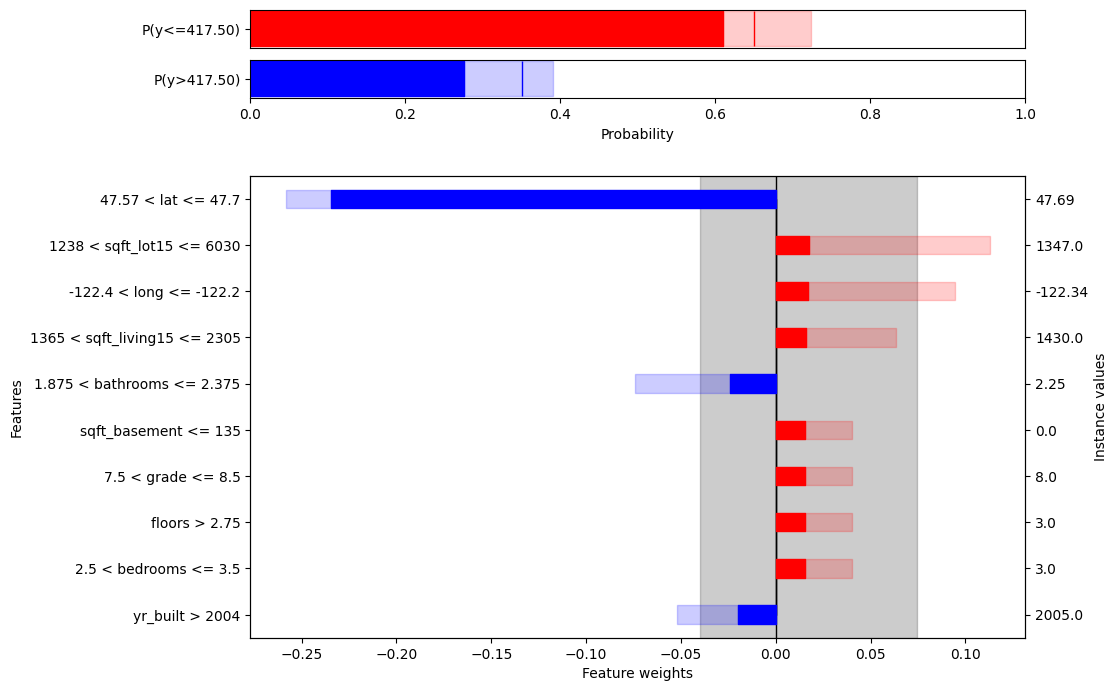

In [ ]:
probabilistic_factual_explanations = regressor.explain_guarded_factual(x_test, threshold=y_test + 20)
probabilistic_factual_explanations.plot()
probabilistic_factual_explanations.plot(uncertainty=True)

C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:618: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


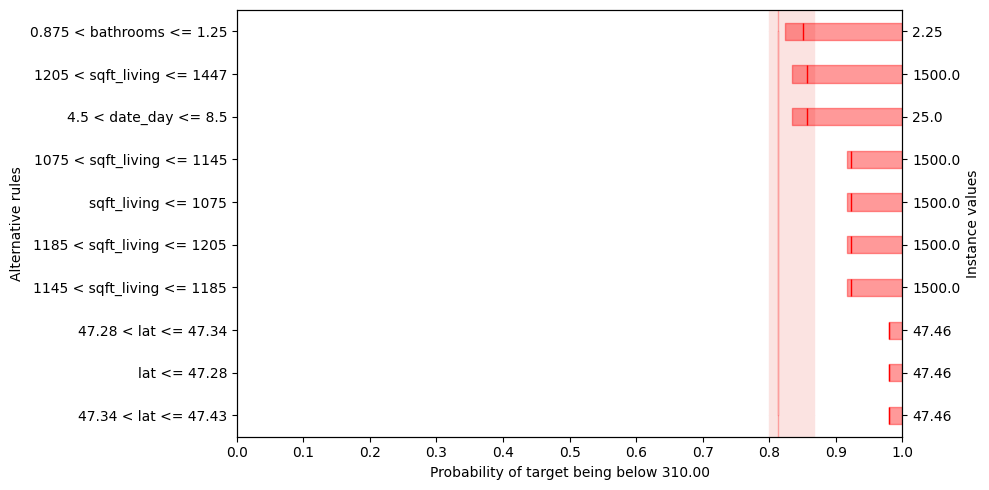

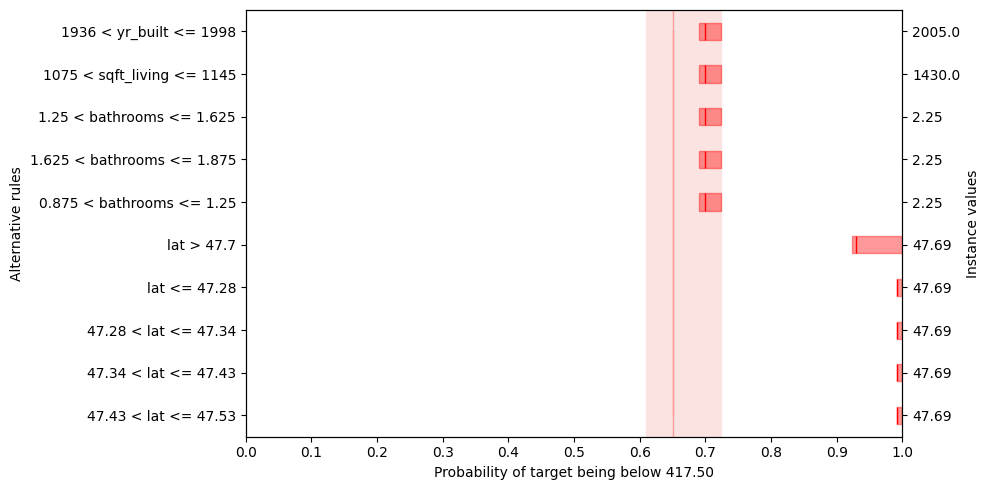

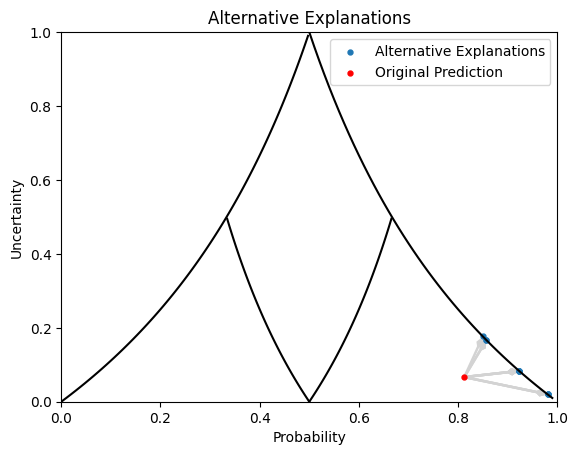

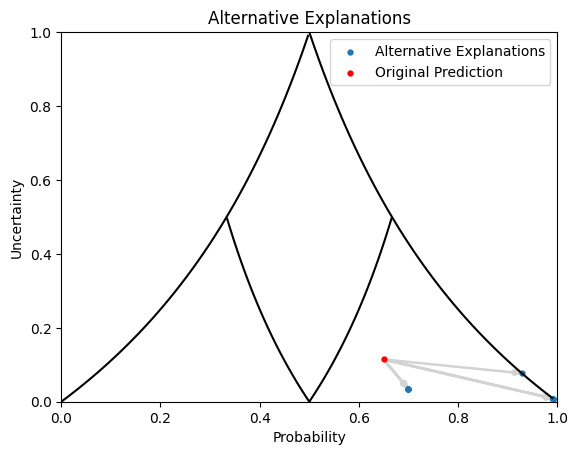


Instance 0

Alternative Explanation (Advanced):
--------------------------------------------------------------------------------
Calibrated Probability (target <= 310.000): 0.812
Prediction Interval: [0.800, 0.867]

Alternatives to increase the Calibrated Probability for target <= 310.000:
- If lat 47.28 < lat <= 47.34                       then P(target <= 310.000) = 0.980 [0.980, 1.000]
- If lat 47.34 < lat <= 47.43                       then P(target <= 310.000) = 0.980 [0.980, 1.000]
- If lat <= 47.28                                   then P(target <= 310.000) = 0.980 [0.980, 1.000]
- If sqft_living 1075 < sqft_living <= 1145         then P(target <= 310.000) = 0.923 [0.917, 1.000]
- If sqft_living 1145 < sqft_living <= 1185         then P(target <= 310.000) = 0.923 [0.917, 1.000]
- If sqft_living 1185 < sqft_living <= 1205         then P(target <= 310.000) = 0.923 [0.917, 1.000]
- If sqft_living <= 1075                            then P(target <= 310.000) = 0.923 [0.917, 1.000]
-

In [ ]:
probabilistic_alternative_explanations = regressor.explore_guarded_alternatives(x_test, threshold=y_test + 20)
probabilistic_alternative_explanations.plot()
probabilistic_alternative_explanations.plot(style="ensured")
print(probabilistic_alternative_explanations.to_narrative(expertise_level="advanced",output_format="text"))

Regression offers many more options but to learn more about them, see the [demo_regression](https://github.com/Moffran/calibrated_explanations/blob/main/notebooks/demo_regression.ipynb) or the [demo_probabilistic_regression](https://github.com/Moffran/calibrated_explanations/blob/main/notebooks/demo_probabilistic_regression.ipynb) notebooks.

A `WrapCalibratedExplainer` can also be initialized with a trained model or with a `WrapCalibratedExplainer` object, as is examplified below. We use the `learner` and `explainer` from the previously initialized `classifier` and `regressor` instances, as we know that these are fitted and calibrated.  

In [ ]:
new_classifier = WrapCalibratedExplainer(classifier.learner)
display(new_classifier)
new_classifier_explainer = WrapCalibratedExplainer(classifier.explainer)
display(new_classifier_explainer)

new_regressor = WrapCalibratedExplainer(regressor.learner)
display(new_regressor)
new_regressor_explainer = WrapCalibratedExplainer(regressor.explainer)
display(new_regressor_explainer)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=False)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, discretizer=EntropyDiscretizer(), learner=RandomForestClassifier()))

WrapCalibratedExplainer(learner=RandomForestRegressor(), fitted=True, calibrated=False)

WrapCalibratedExplainer(learner=RandomForestRegressor(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=regression, discretizer=RegressorDiscretizer(), learner=RandomForestRegressor(), difficulty_estimator=DifficultyEstimator(fitted=True, type=variance, scaler=True, beta=0.01, oob=False)))

When a calibrated explainer is re-fitted, the explainer is reinitialized.